In [1]:
import pandas as pd

data = pd.read_csv("../data/DataCoSupplyChainDataset.csv", encoding='latin1')

print(data.shape)
print(data["Delivery Status"].value_counts())
print(data["Late_delivery_risk"].value_counts())



data = data[data["Delivery Status"] != "Shipping canceled"]

def map_status(x):
    if x == "Late delivery":
        return "Delayed"
    else:
        return "On-Time"

data["Delivery_Class"] = data["Delivery Status"].apply(map_status)

print(data["Delivery_Class"].value_counts())

data[["Days for shipping (real)", "Days for shipment (scheduled)"]].head()



data["delay_days"] = data["Days for shipping (real)"] - data["Days for shipment (scheduled)"]

def classify_delay(x):
    if x <= 0:
        return "On-Time"
    elif x == 1:
        return "At Risk"
    else:
        return "Delayed"

data["Final_Delivery_Class"] = data["delay_days"].apply(classify_delay)


print(data["Final_Delivery_Class"].value_counts())

(180519, 53)
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64
Delivery_Class
Delayed    98977
On-Time    73788
Name: count, dtype: int64
Final_Delivery_Class
On-Time    73788
At Risk    57957
Delayed    41020
Name: count, dtype: int64


In [3]:
data.columns
columns_to_drop = [
    "Delivery Status",
    "Late_delivery_risk",
    "Customer Email",
    "Customer Fname",
    "Customer Lname",
    "Customer Password",
    "Product Description",
    "Product Image",
    "Order Zipcode",
    "Customer Zipcode",
    "Order Id",
    "Order Item Id"
]

data = data.drop(columns=columns_to_drop, errors="ignore")

print(data.shape)


(172765, 44)


In [4]:

X = data.drop("Final_Delivery_Class", axis=1)
y = data["Final_Delivery_Class"]

print(X.shape)
print(y.shape)

(172765, 43)
(172765,)


In [5]:
X.select_dtypes(include="object").columns

Index(['Type', 'Category Name', 'Customer City', 'Customer Country',
       'Customer Segment', 'Customer State', 'Customer Street',
       'Department Name', 'Market', 'Order City', 'Order Country',
       'order date (DateOrders)', 'Order Region', 'Order State',
       'Order Status', 'Product Name', 'shipping date (DateOrders)',
       'Shipping Mode', 'Delivery_Class'],
      dtype='object')

In [6]:
columns_to_drop_more = [
    "Delivery_Class",
    "Order Status",
    "order date (DateOrders)",
    "shipping date (DateOrders)",
    "Customer Street",
    "Product Name"
]

X = X.drop(columns=columns_to_drop_more, errors="ignore")

print(X.shape)

X.columns

(172765, 37)


Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Category Id',
       'Category Name', 'Customer City', 'Customer Country', 'Customer Id',
       'Customer Segment', 'Customer State', 'Department Id',
       'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City',
       'Order Country', 'Order Customer Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State',
       'Product Card Id', 'Product Category Id', 'Product Price',
       'Product Status', 'Shipping Mode', 'delay_days'],
      dtype='object')

In [7]:
leakage_columns = [
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "delay_days"
]

X = X.drop(columns=leakage_columns, errors="ignore")

print(X.shape)

id_columns = [
    "Customer Id",
    "Order Customer Id",
    "Order Item Cardprod Id",
    "Product Card Id",
    "Category Id",
    "Department Id",
    "Product Category Id"
]

X = X.drop(columns=id_columns, errors="ignore")

print(X.shape)

(172765, 34)
(172765, 27)


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include="object").columns:
    X[col] = le.fit_transform(X[col].astype(str))

print("Encoding Done")

Encoding Done


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)

(138212, 27)


In [10]:
leakage_columns = [
    "Days for shipping (real)",
    "Order Status",
    "Delivery Status",
    "Late_delivery_risk",
    "Delivery_Class",
    "delay_days"
]

data = data.drop(columns=leakage_columns, errors="ignore")

In [11]:
X = data.drop("Final_Delivery_Class", axis=1)
y = data["Final_Delivery_Class"]

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import joblib


X = data.drop("Final_Delivery_Class", axis=1)
y = data["Final_Delivery_Class"]


categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(exclude="object").columns


preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)


pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


pipeline.fit(X_train, y_train)


y_pred = pipeline.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


joblib.dump(pipeline, "best_model.pkl")

              precision    recall  f1-score   support

     At Risk       0.98      0.77      0.87     11523
     Delayed       0.90      0.76      0.82      8276
     On-Time       0.77      0.96      0.86     14754

    accuracy                           0.85     34553
   macro avg       0.88      0.83      0.85     34553
weighted avg       0.87      0.85      0.85     34553



['best_model.pkl']

In [13]:
data.columns

Index(['Type', 'Days for shipment (scheduled)', 'Benefit per order',
       'Sales per customer', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Id', 'Customer Segment', 'Customer State',
       'Customer Street', 'Department Id', 'Department Name', 'Latitude',
       'Longitude', 'Market', 'Order City', 'Order Country',
       'Order Customer Id', 'order date (DateOrders)',
       'Order Item Cardprod Id', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Product Price',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Order Region',
       'Order State', 'Product Card Id', 'Product Category Id', 'Product Name',
       'Product Price', 'Product Status', 'shipping date (DateOrders)',
       'Shipping Mode', 'Final_Delivery_Class'],
      dtype='object')

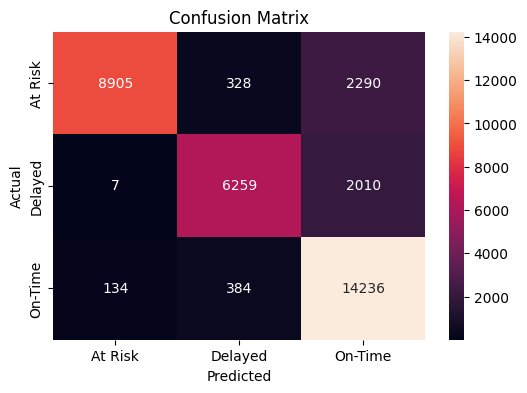

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=pipeline.named_steps["model"].classes_,
    yticklabels=pipeline.named_steps["model"].classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [16]:
import pandas as pd


rf = pipeline.named_steps["model"]   

feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()


feature_importance = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(feature_importance.head(15))

num__Days for shipment (scheduled)    0.078847
cat__Shipping Mode_First Class        0.068294
cat__Shipping Mode_Second Class       0.043087
cat__Shipping Mode_Standard Class     0.042438
num__Order Customer Id                0.009205
num__Customer Id                      0.009076
num__Latitude                         0.008959
cat__Shipping Mode_Same Day           0.008661
num__Longitude                        0.008558
num__Benefit per order                0.008328
num__Order Profit Per Order           0.008245
num__Order Item Profit Ratio          0.007780
num__Sales per customer               0.007624
num__Order Item Total                 0.007576
num__Order Item Discount              0.007478
dtype: float64


<Axes: >

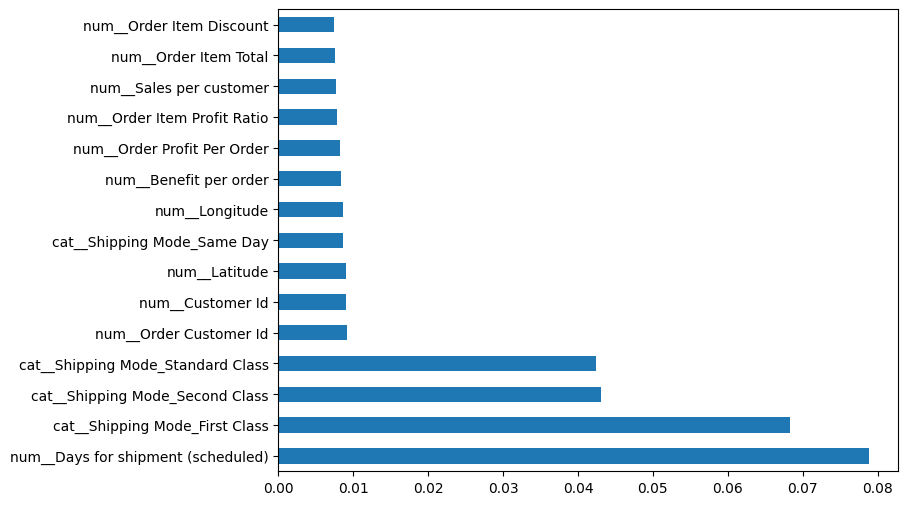

In [17]:
feature_importance.head(15).plot(kind="barh", figsize=(8,6))


In [18]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),   
    ("model", GradientBoostingClassifier(random_state=42))
])

gb_pipeline.fit(X_train, y_train)


y_pred_gb = gb_pipeline.predict(X_test)


print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

     At Risk       0.96      0.49      0.65     11523
     Delayed       0.60      0.50      0.54      8276
     On-Time       0.60      0.89      0.72     14754

    accuracy                           0.66     34553
   macro avg       0.72      0.63      0.64     34553
weighted avg       0.72      0.66      0.65     34553



In [ ]:


from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score


le_target = LabelEncoder()

y_train_encoded = le_target.fit_transform(y_train)
y_test_encoded = le_target.transform(y_test)


xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric="mlogloss",
        use_label_encoder=False
    ))
])

xgb_pipeline.fit(X_train, y_train_encoded)


y_pred_xgb = xgb_pipeline.predict(X_test)


print("XGBoost Classification Report:\n")
print(classification_report(y_test_encoded, y_pred_xgb))

print("Accuracy:", accuracy_score(y_test_encoded, y_pred_xgb))
print("Weighted F1:", f1_score(y_test_encoded, y_pred_xgb, average="weighted"))

C:\Users\acer.DESKTOP-SAIO2RF\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [23:12:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.49      0.65     11523
           1       0.60      0.50      0.55      8276
           2       0.60      0.90      0.72     14754

    accuracy                           0.66     34553
   macro avg       0.73      0.63      0.64     34553
weighted avg       0.73      0.66      0.65     34553

Accuracy: 0.6643706769310914
Weighted F1: 0.6547409737995303


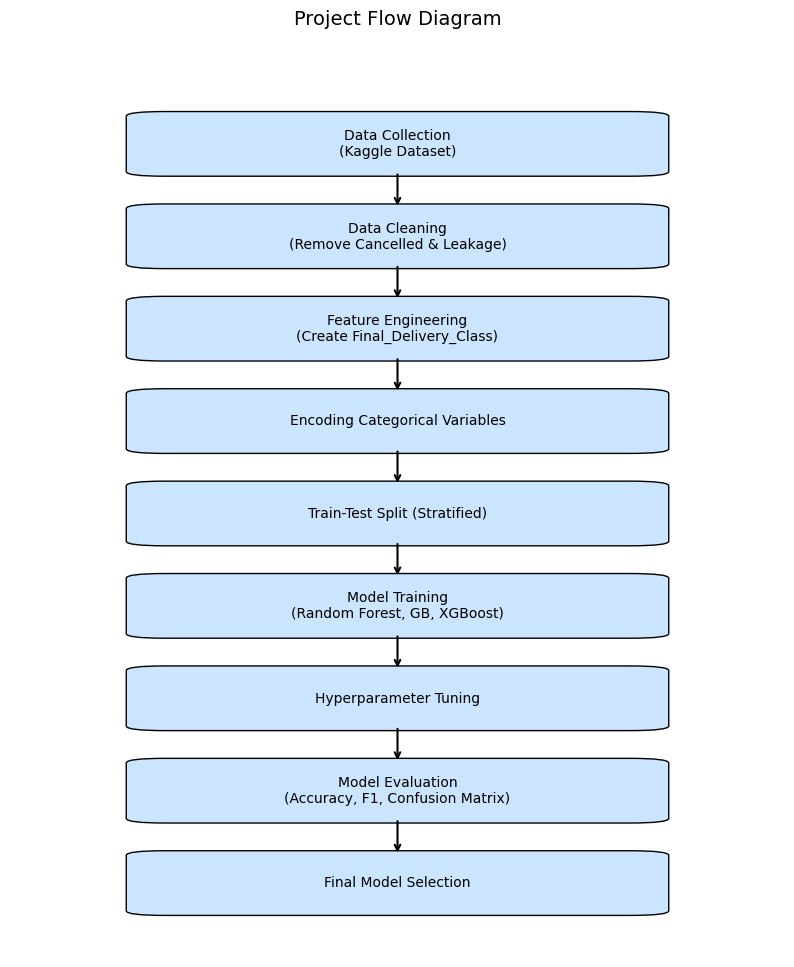

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(10, 12))

steps = [
    "Data Collection\n(Kaggle Dataset)",
    "Data Cleaning\n(Remove Cancelled & Leakage)",
    "Feature Engineering\n(Create Final_Delivery_Class)",
    "Encoding Categorical Variables",
    "Train-Test Split (Stratified)",
    "Model Training\n(Random Forest, GB, XGBoost)",
    "Hyperparameter Tuning",
    "Model Evaluation\n(Accuracy, F1, Confusion Matrix)",
    "Final Model Selection"
]

y_positions = list(range(len(steps), 0, -1))

for y, step in zip(y_positions, steps):
    ax.add_patch(
        patches.FancyBboxPatch(
            (0.2, y-0.5),
            0.6,
            0.6,
            boxstyle="round,pad=0.05",
            edgecolor="black",
            facecolor="#cce5ff"
        )
    )
    ax.text(0.5, y-0.2, step, ha='center', va='center', fontsize=10)

for y in y_positions[:-1]:
    ax.annotate(
        '',
        xy=(0.5, y-0.5),
        xytext=(0.5, y-0.9),
        arrowprops=dict(arrowstyle="<-", linewidth=1.5)
    )

ax.set_xlim(0, 1)
ax.set_ylim(0, len(steps)+1)
ax.axis('off')

plt.title("Project Flow Diagram", fontsize=14)
plt.show()

In [20]:
y = data["Final_Delivery_Class"]
print(type(y))

<class 'pandas.core.series.Series'>


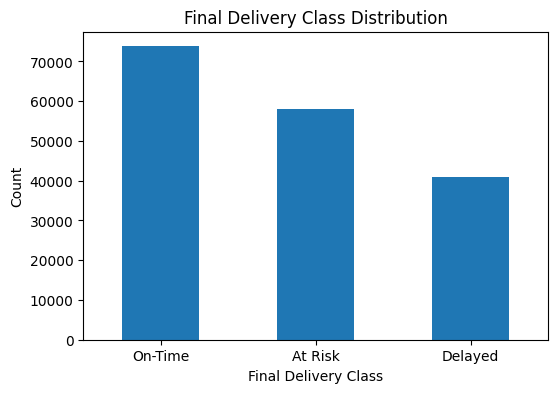

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
y.value_counts().plot(kind='bar')
plt.xlabel("Final Delivery Class")
plt.ylabel("Count")
plt.title("Final Delivery Class Distribution")
plt.xticks(rotation=0)
plt.show()

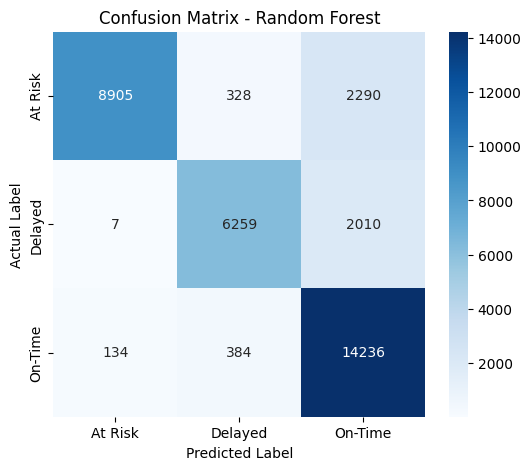

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Use correct prediction variable
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=pipeline.named_steps["model"].classes_,
    yticklabels=pipeline.named_steps["model"].classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

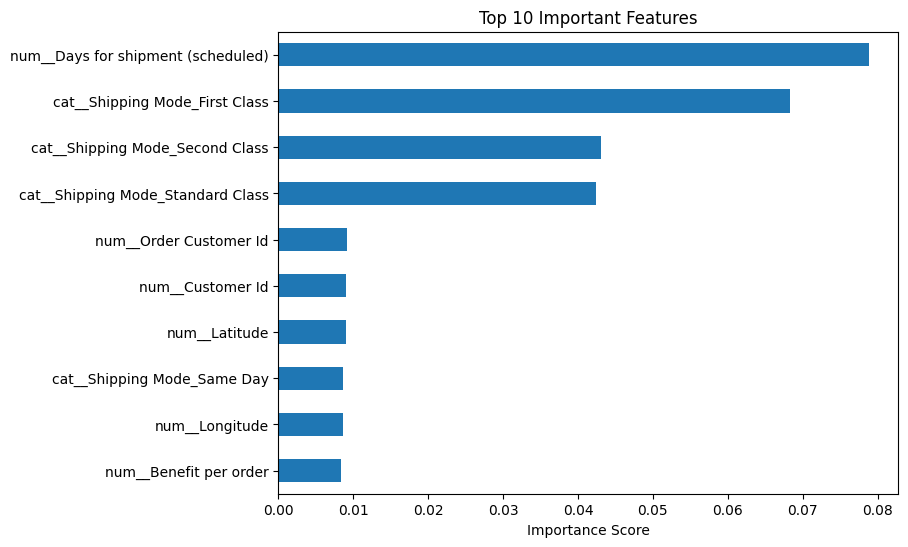

In [25]:
import pandas as pd
import matplotlib.pyplot as plt


rf = pipeline.named_steps["model"]  

feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

feature_importance = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)


plt.figure(figsize=(8,6))
feature_importance.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Top 10 Important Features")
plt.show()

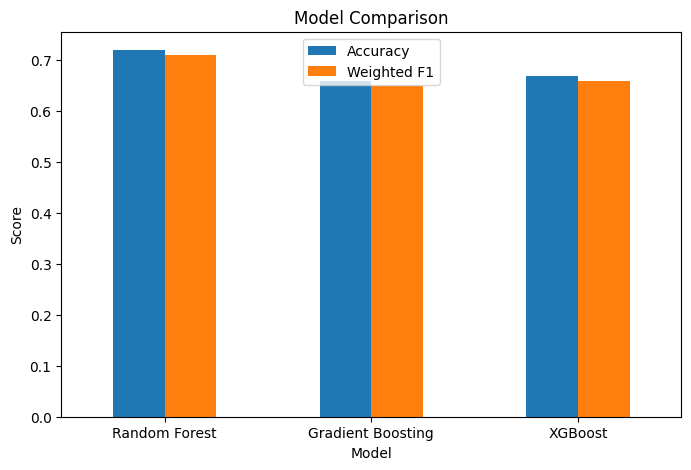

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

models = ["Random Forest", "Gradient Boosting", "XGBoost"]
accuracy_scores = [0.72, 0.66, 0.67]   
f1_scores = [0.71, 0.65, 0.66]        

comparison_df = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy_scores,
    "Weighted F1": f1_scores
})

comparison_df.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

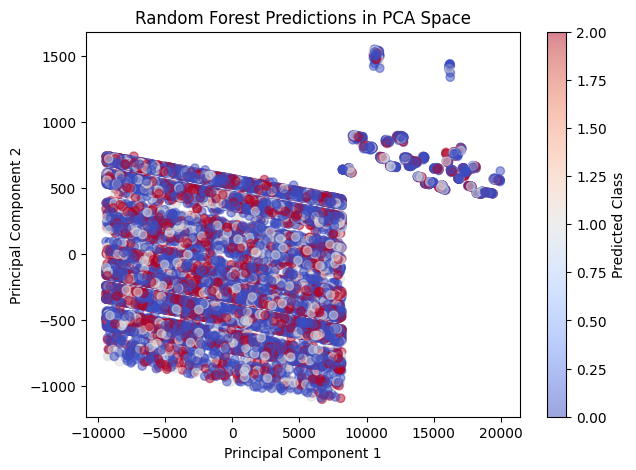

In [27]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np


model_pipeline = pipeline   


y_pred_labels = model_pipeline.predict(X_test)


X_processed = model_pipeline.named_steps["preprocessor"].transform(X_test)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)


unique_labels = list(set(y_pred_labels))
label_mapping = {label: idx for idx, label in enumerate(unique_labels)}
numeric_labels = [label_mapping[label] for label in y_pred_labels]


plt.figure(figsize=(7,5))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=numeric_labels,
    cmap='coolwarm',
    alpha=0.5
)

plt.title("Random Forest Predictions in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Predicted Class")
plt.show()

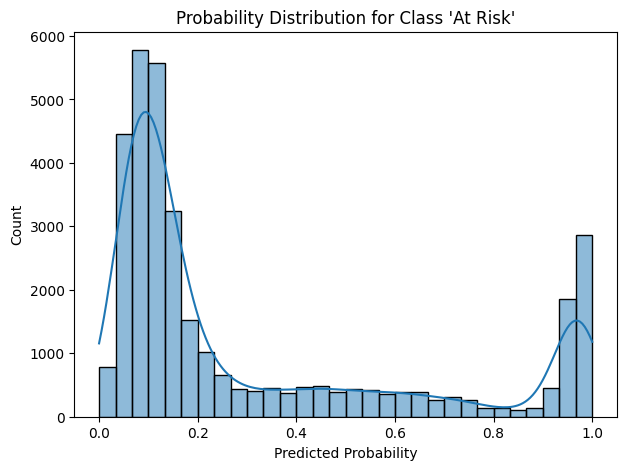

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


model_pipeline = pipeline   

probs = model_pipeline.predict_proba(X_test)


class_labels = model_pipeline.named_steps["model"].classes_


class_index = list(class_labels).index("At Risk")


plt.figure(figsize=(7,5))
sns.histplot(probs[:, class_index], bins=30, kde=True)

plt.title("Probability Distribution for Class 'At Risk'")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.show()

In [29]:
import joblib

joblib.dump(pipeline, "best_model.pkl")

['best_model.pkl']

In [30]:
feature_names = X.columns.tolist()
print(feature_names)

['Type', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Id', 'Customer Segment', 'Customer State', 'Customer Street', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Product Card Id', 'Product Category Id', 'Product Name', 'Product Price', 'Product Status', 'shipping date (DateOrders)', 'Shipping Mode']


In [31]:
import joblib
joblib.dump(feature_names, "../feature_names.pkl")

['../feature_names.pkl']

In [32]:
joblib.dump(X_train.iloc[:1], "../feature_template.pkl")

['../feature_template.pkl']

In [33]:
import sys
print(sys.executable)

C:\Users\acer.DESKTOP-SAIO2RF\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe
